In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
import os
os.getcwd()

'/Users/bradlarson'

In [5]:
import os
os.chdir("/Users/bradlarson/Desktop/Applied-Project")


In [7]:
df= pd.read_csv("V2_ML_Water_Usage_Dataset.csv")
df.head()

,Wafer Step,Year,Synthetic_Water_per_Wafer,Synthetic_Water_per_Wafer_noisy,Investment_Level,Wafer_Size,Water_Efficiency_Level,Percent_Reclaimed_Water,Percent_Municipal_Water,Reclamation_Tech_Level,Wafer_Intention,Investment_Efficiency,Water_Stress_Index,Composite_Risk_Score,Year_Squared
0,Cleaning,1,0.000032,0.000034,218.543054,300,Low,82.021890,17.978110,5,Reduced,43.708611,5393.433070,146.106567,1
1,Cleaning,2,0.000033,0.000032,477.821438,300,Low,64.720525,35.279475,4,Reduced,119.455360,10583.842650,140.616157,4
2,Cleaning,3,0.000034,0.000035,379.397274,300,Low,56.316925,43.683075,5,Advanced,75.879455,13104.922450,138.395078,9
3,Cleaning,4,0.000035,0.000035,319.396318,450,Medium,73.515460,26.484540,2,Advanced,159.698159,11918.043170,202.654638,16
4,Cleaning,5,0.000036,0.000035,120.208388,200,Medium,59.200136,40.799864,4,Current,30.052097,8159.972703,98.960041,25


In [9]:
df_encoded = df.copy()
label_cols = ['Wafer Step', 'Water_Efficiency_Level', 'Wafer_Intention']
encoder_dict = {}

In [11]:
for col in label_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoder_dict[col] = le

In [13]:
# 4. Simulate Defect Risk Score
def simulate_defect_risk(row):
    base_risk = 0.2

    if row['Percent_Reclaimed_Water'] < 50:
        base_risk += 0.2
    elif row['Percent_Reclaimed_Water'] < 70:
        base_risk += 0.1
    else:
        base_risk -= 0.1

    if row['Water_Efficiency_Level'] == 0:
        base_risk += 0.2
    elif row['Water_Efficiency_Level'] == 1:
        base_risk += 0.1
    else:
        base_risk -= 0.05

    if row['Reclamation_Tech_Level'] < 3:
        base_risk += 0.15
    elif row['Reclamation_Tech_Level'] >= 4:
        base_risk -= 0.1

    if row['Investment_Efficiency'] < 75:
        base_risk += 0.15
    elif row['Investment_Efficiency'] > 150:
        base_risk -= 0.1

    return round(min(max(base_risk, 0.0), 1.0), 4)

df_encoded['Defect_Risk_Score'] = df_encoded.apply(simulate_defect_risk, axis=1)


In [19]:
#Define Features and Target
feature_cols = [
    'Investment_Level', 'Wafer_Size', 'Water_Efficiency_Level',
    'Percent_Reclaimed_Water', 'Percent_Municipal_Water',
    'Reclamation_Tech_Level', 'Wafer_Intention', 'Investment_Efficiency',
    'Water_Stress_Index', 'Composite_Risk_Score', 'Year_Squared'
]
X = df_encoded[feature_cols]
y = df_encoded['Defect_Risk_Score']

In [21]:
# 6. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# 7. Train Model
model = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_split=10, n_estimators=300,
                      random_state=42)

In [30]:
# 8. Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.5f}")
print(f"R² Score: {r2:.3f}")

MAE: 0.04339
R² Score: 0.869


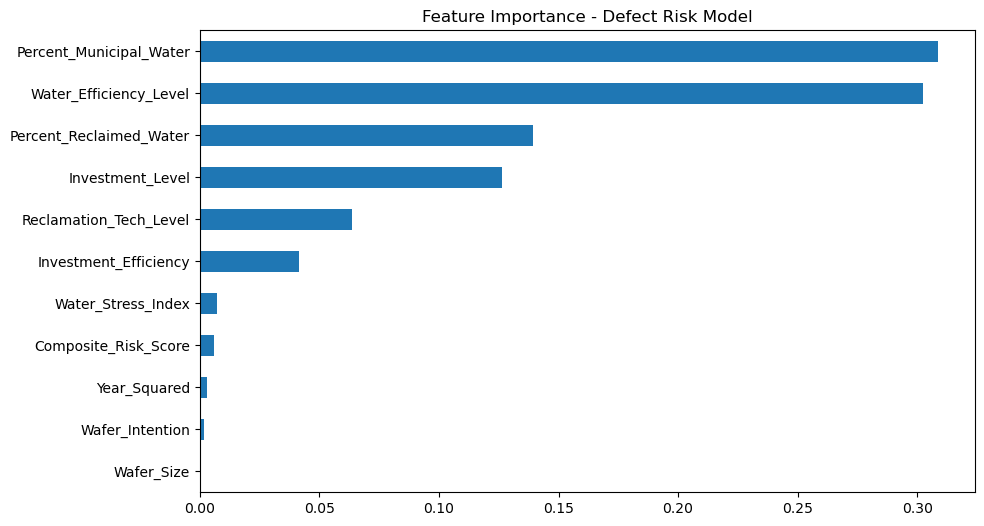

In [32]:
# 9. Optional: Visualize Feature Importance
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', figsize=(10,6), title="Feature Importance - Defect Risk Model")
plt.show()